<a href="https://colab.research.google.com/github/amankiitg/5DParallel/blob/main/SLM_Dense_vs_MoE_TinyStories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Let us build a Small Language Model (SLM) from scratch. We will try to keep the parameter size to 50-60 million.

Our goal is to generate creative and coherent text based on the input data.

## Step 1: Import the Dataset

TinyStories is a synthetic dataset of short stories that only contain words that a typical 3 to 4-year-olds usually understand, generated by GPT-3.5 and GPT-4. We can get it from HuggingFace.

In [ ]:
!pip install datasets

In [ ]:
pip install -U datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 59.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

## Step 2: Tokenize the Dataset

In this step, we will do the following:

(1) Tokenize the dataset into tokenIDs.

(2) Create a file called "train.bin" and "validtion.bin" where we will store the tokenIDs from the entire dataset.

(3) We make sure the tokenIDs are stored on a disk, rather than on the RAM for efficient computations.

In [ ]:
!pip install tiktoken
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py

def process(example):
    ids = enc.encode_ordinary(example['text']) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

tokenizing the splits (num_proc=8):   0%|          | 0/2119719 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/21990 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

## Step 3: Create Input-Output batches for the dataset

In [ ]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


## Step 4: Define the SLM Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx



In [ ]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

## Step 5: Define the loss function

In [ ]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 6: Define SLM Training Configuration Part 1

In [ ]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 20000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

## Step 7: Define SLM Training Configuration Part 2

In [ ]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipykernel_675/2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


## Step 8: Pre-train the SLM

In [ ]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 500: train loss 9.4230, val loss 9.4289
The current learning rate: 0.00007
Epoch 1000: train loss 8.4598, val loss 8.4672
The current learning rate: 0.00010
Epoch 1500: train loss 7.5133, val loss 7.5127
The current learning rate: 0.00010
Epoch 2000: train loss 6.6590, val loss 6.6588
The current learning rate: 0.00010
Epoch 2500: train loss 5.9683, val loss 5.9671
The current learning rate: 0.00011
Epoch 3000: train loss 5.4604, val loss 5.4574
The current learning rate: 0.00011
Epoch 3500: train loss 5.0453, val loss 5.0528
The current learning rate: 0.00012
Epoch 4000: train loss 4.7324, val loss 4.7292
The current learning rate: 0.00012
Epoch 4500: train loss 4.4950, val loss 4.4865
The current learning rate: 0.00013
Epoch 5000: train loss 4.2802, val loss 4.2873
The current learning rate: 0.00014
Epoch 5500: train loss 4.1127, val loss 4.1080
The current learning rate: 0.00015
Epoch 6000: train loss 3.9574, val loss 3.9538
The current learning rate: 0.00016
Epoch 6500: train

## Step 9: Plot the SLM Loss Function

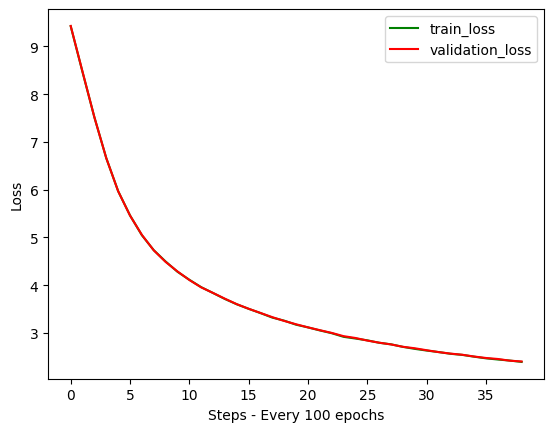

In [ ]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



## Step 10: Run SLM Inference on our trained model

In [ ]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


<All keys matched successfully>

In [ ]:
sentence = "Once upon a time there was a pumpkin."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. It was very special. The pumpkin wanted to paint with its family. So one day, a family decided to make it you all the time. They worked hard to remove something.

 2 laser soldiers traveled and drove it grow into the sky. laughed like the whole."

The pumpkin stopped and smiled and felt happy for the tube. It sounded like it. Give it on big taller than it. They packed it and back up.

When it was done, the pumpkin had closed. It was relaxed and cozy. There were people that flying. Little Thursday workerAlright, the tower could during a bright, normal time. His friend said, "Trn into Lou, what can we do and find our flashlight?"

Her friend thought smellyly and said: "We can try to open it! It can be alright. We can find it". 

Joe was amazed. He wanted that if they could delay, they would come back back and mattered the sign


In [ ]:
sentence = "A little girl went to the woods"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little girl went to the woods and was walking across the forest, baking and looking out of for spending the big naps of rain. The sun was setting and the little girl felt very finishing her brother and went home to sleep. Her mommy and dad had packed her a pair of ice. 

At the end of the day, Lydia was slowly dressed up in sleep and she had so much fun. Her mommy said she wasn't troubled anymore. Her mommy smiled and said, "it is time to go back to life enjoyed life."Once upon a time, there was a little boy named Tommy. Timmy loved to read books and sang. One day, he saw so dependesameages something interesting. It was this and he wanted to pick one. He picked up a zipper from its much chirpy bank, but it was too dangerous. Soon, Tommy was so excited and very upset. 

His mommy took him to the mailbox and it gave him lots of toys to clean up


---
# Part 2: Mixture of Experts (MoE) — Smarter FFN Layers

In Part 1, every transformer block used a **single dense FFN (MLP)** — every token
passes through ALL the FFN parameters every time.

Now we replace that FFN with a **Mixture of Experts (MoE)** layer:
- Instead of 1 FFN, we have **4 expert FFNs** (each identical in architecture to the original MLP)
- A **learned router** decides which 2 experts (top-2) each token should use
- Each token only activates 2 out of 4 experts → **sparse computation**

This gives us **more model capacity** (4x more FFN parameters) while each token only
uses ~2x the FFN compute. The key question: **does this extra capacity translate to lower loss?**

```
Dense Block:                    MoE Block:
┌─────────────┐                ┌─────────────┐
│  Attention   │                │  Attention   │  ← identical
├─────────────┤                ├─────────────┤
│             │                │   Router     │  ← NEW: picks top-2 experts
│  Single MLP │                ├──┬──┬──┬──┤
│  (all tokens)│                │E0│E1│E2│E3│  ← 4 separate MLPs
│             │                ├──┴──┴──┴──┤
│             │                │ Weighted Sum │  ← combine top-2 outputs
└─────────────┘                └─────────────┘
```


## Step 11: Define the MoE Architecture

We need three new components:
1. **Router** — A small linear layer that scores each expert for each token, then picks top-k
2. **SparseMoELayer** — Routes tokens to their top-k experts, runs only those experts, combines outputs
3. **MoEBlock** — Same as the original `Block`, but with `SparseMoELayer` replacing `MLP`

Everything else (attention, embeddings, positional encoding) stays **identical** to Part 1.

We also add a **load balancing auxiliary loss** that encourages the router to distribute
tokens evenly across experts (prevents "expert collapse" where one expert hogs all tokens).


In [ ]:
# ─── Router: decides which experts each token uses ───

class Router(nn.Module):
    """Learned gating network that assigns tokens to top-k experts."""
    def __init__(self, n_embd, num_experts, top_k):
        super().__init__()
        self.top_k = top_k
        self.gate = nn.Linear(n_embd, num_experts, bias=False)

    def forward(self, x):
        # x: (B, T, C) -> router_logits: (B, T, num_experts)
        router_logits = self.gate(x)
        # Pick top-k experts per token
        top_k_logits, top_k_indices = torch.topk(router_logits, self.top_k, dim=-1)
        # Softmax ONLY over the selected top-k (not all experts)
        top_k_weights = F.softmax(top_k_logits, dim=-1)
        return top_k_weights, top_k_indices, router_logits


# ─── Sparse MoE Layer: the core MoE logic ───

class SparseMoELayer(nn.Module):
    """Sparse Mixture of Experts — replaces the single MLP in each block."""
    def __init__(self, config):
        super().__init__()
        self.num_experts = config.num_experts
        self.top_k = config.top_k
        # Each expert is the SAME MLP architecture from the dense model
        self.experts = nn.ModuleList([MLP(config) for _ in range(config.num_experts)])
        self.router = Router(config.n_embd, config.num_experts, config.top_k)

    def forward(self, x):
        B, T, C = x.shape

        # Step 1: Get routing decisions
        routing_weights, selected_experts, router_logits = self.router(x)
        # routing_weights:   (B, T, top_k) — softmaxed weights for selected experts
        # selected_experts:  (B, T, top_k) — indices of chosen experts
        # router_logits:     (B, T, num_experts) — raw logits (for aux loss)

        # Flatten batch and sequence for easier token-level processing
        x_flat = x.view(-1, C)                                    # (B*T, C)
        weights_flat = routing_weights.view(-1, self.top_k)       # (B*T, top_k)
        experts_flat = selected_experts.view(-1, self.top_k)      # (B*T, top_k)

        # Step 2: Run each expert ONLY on its assigned tokens (sparse!)
        output = torch.zeros_like(x_flat)  # (B*T, C)

        for i, expert in enumerate(self.experts):
            # Which tokens selected this expert? (across any of the top-k slots)
            mask = (experts_flat == i)              # (B*T, top_k) boolean
            token_mask = mask.any(dim=-1)           # (B*T,) — True if token uses expert i

            if not token_mask.any():
                continue  # No tokens for this expert — skip

            # Run expert ONLY on selected tokens
            expert_input = x_flat[token_mask]       # (num_selected, C)
            expert_output = expert(expert_input)     # (num_selected, C)

            # Get this expert's weight for each selected token
            # (sum across k-slots in case expert appears in multiple slots)
            expert_weights = (weights_flat * mask.float()).sum(dim=-1)  # (B*T,)
            expert_weights = expert_weights[token_mask]                 # (num_selected,)

            # Weighted contribution to output
            output[token_mask] += expert_output * expert_weights.unsqueeze(-1)

        output = output.view(B, T, C)

        # Step 3: Compute load balancing auxiliary loss
        aux_loss = self._load_balancing_loss(router_logits, selected_experts)

        return output, aux_loss

    def _load_balancing_loss(self, router_logits, selected_experts):
        """Auxiliary loss that encourages balanced expert utilization.
        From Switch Transformer: L_aux = N * sum(f_i * P_i)
        where f_i = fraction of tokens routed to expert i
              P_i = mean router probability for expert i
        """
        B, T, _ = router_logits.shape
        num_tokens = B * T

        # f_i: fraction of tokens dispatched to each expert
        flat_experts = selected_experts.view(-1, self.top_k)  # (B*T, top_k)
        expert_mask = torch.zeros(num_tokens, self.num_experts, device=router_logits.device)
        expert_mask.scatter_(1, flat_experts, 1.0)  # mark which experts each token uses
        f = expert_mask.mean(dim=0)  # (num_experts,)

        # P_i: mean router probability for each expert
        P = F.softmax(router_logits, dim=-1).mean(dim=(0, 1))  # (num_experts,)

        # Auxiliary loss: minimized when routing is perfectly balanced
        aux_loss = self.num_experts * (f * P).sum()
        return aux_loss

print("Router and SparseMoELayer defined!")


Router and SparseMoELayer defined!


In [ ]:
# ─── MoE Transformer Block and Full Model ───

class MoEBlock(nn.Module):
    """Transformer block with MoE replacing the FFN."""
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.moe = SparseMoELayer(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        moe_out, aux_loss = self.moe(self.ln2(x))
        x = x + moe_out
        return x, aux_loss


@dataclass
class MoEGPTConfig:
    block_size: int = 128
    vocab_size: int = 50257
    n_layer: int = 6
    n_head: int = 6
    n_embd: int = 384
    dropout: float = 0.1
    bias: bool = True
    num_experts: int = 4     # number of expert MLPs per layer
    top_k: int = 2           # each token uses top-2 experts
    aux_loss_weight: float = 0.01  # weight for load balancing loss


class MoEGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([MoEBlock(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        # Track losses for monitoring
        self.last_lm_loss = 0.0
        self.last_aux_loss = 0.0

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)

        # Collect auxiliary losses from each MoE layer
        total_aux_loss = 0.0
        for block in self.transformer.h:
            x, aux_loss = block(x)
            total_aux_loss += aux_loss
        total_aux_loss /= self.config.n_layer  # average across layers

        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            lm_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            loss = lm_loss + self.config.aux_loss_weight * total_aux_loss
            self.last_lm_loss = lm_loss.item()
            self.last_aux_loss = total_aux_loss.item() if torch.is_tensor(total_aux_loss) else total_aux_loss
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

print("MoEBlock, MoEGPTConfig, and MoEGPT defined!")


MoEBlock, MoEGPTConfig, and MoEGPT defined!


## Step 12: Create MoE Model & Compare Parameter Counts

Let's instantiate the MoE model with the **same config** as the dense model,
plus the MoE-specific settings (4 experts, top-2 routing).

Then we'll count parameters to see the tradeoff:
- **Total parameters**: How much memory does the model need?
- **Active parameters per token**: How much compute does each token require?


In [ ]:
moe_config = MoEGPTConfig(
    vocab_size=50257,
    block_size=128,
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True,
    num_experts=4,        # 4 expert MLPs per layer
    top_k=2,              # each token activates 2 experts
    aux_loss_weight=0.01  # load balancing coefficient
)

moe_model = MoEGPT(moe_config)
moe_model = moe_model.to(device)

# ─── Parameter Count Comparison ───
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

dense_params = count_parameters(GPT(config))
moe_total_params = count_parameters(moe_model)

# Active params per token: shared layers + top_k/num_experts fraction of expert params
# Expert params = all MoE expert weights
expert_params = sum(
    p.numel()
    for name, p in moe_model.named_parameters()
    if 'experts' in name
)
router_params = sum(
    p.numel()
    for name, p in moe_model.named_parameters()
    if 'router' in name or 'gate' in name
)
shared_params = moe_total_params - expert_params
active_expert_params = expert_params * (moe_config.top_k / moe_config.num_experts)
moe_active_params = shared_params + active_expert_params

print("=" * 60)
print("         PARAMETER COMPARISON: Dense vs MoE")
print("=" * 60)
print(f"{'Metric':<30} {'Dense':>12} {'MoE':>12}")
print("-" * 60)
print(f"{'Total Parameters':<30} {dense_params/1e6:>11.2f}M {moe_total_params/1e6:>11.2f}M")
print(f"{'Active Params/Token':<30} {dense_params/1e6:>11.2f}M {moe_active_params/1e6:>11.2f}M")
print(f"{'Expert Params (total)':<30} {'N/A':>12} {expert_params/1e6:>11.2f}M")
print(f"{'Router Params':<30} {'N/A':>12} {router_params/1e6:>11.4f}M")
print("-" * 60)
print(f"{'Capacity Ratio (total)':<30} {'1.00x':>12} {moe_total_params/dense_params:>11.2f}x")
print(f"{'Compute Ratio (active)':<30} {'1.00x':>12} {moe_active_params/dense_params:>11.2f}x")
print("=" * 60)
print(f"\nMoE has {moe_total_params/dense_params:.1f}x more total capacity")
print(f"but only {moe_active_params/dense_params:.1f}x more compute per token!")


         PARAMETER COMPARISON: Dense vs MoE
Metric                                Dense          MoE
------------------------------------------------------------
Total Parameters                     30.00M       51.27M
Active Params/Token                  30.00M       37.09M
Expert Params (total)                   N/A       28.36M
Router Params                           N/A      0.0092M
------------------------------------------------------------
Capacity Ratio (total)                1.00x        1.71x
Compute Ratio (active)                1.00x        1.24x

MoE has 1.7x more total capacity
but only 1.2x more compute per token!


## Step 13: MoE Loss Function & Training Setup

We use the **exact same hyperparameters** as the dense model so the comparison is fair:
same learning rate, same scheduler, same batch size, same number of iterations.

The only addition is a modified `estimate_loss` that separately tracks:
- **LM Loss** (cross-entropy) — directly comparable to the dense model
- **Aux Loss** (load balancing) — MoE-specific, encourages balanced routing


In [ ]:
def estimate_loss_moe(model):
    """Estimate loss for MoE model, tracking LM loss separately from aux loss."""
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            lm_losses = torch.zeros(eval_iters)
            aux_losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                lm_losses[k] = model.last_lm_loss
                aux_losses[k] = model.last_aux_loss
            out[split] = lm_losses.mean()
            out[f'{split}_aux'] = aux_losses.mean()
    model.train()
    return out

# ─── Training setup (same hyperparameters as dense model) ───
torch.manual_seed(42)

moe_optimizer = torch.optim.AdamW(
    moe_model.parameters(), lr=learning_rate,
    betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9
)

moe_scheduler_warmup = LinearLR(moe_optimizer, total_iters=warmup_steps)
moe_scheduler_decay = CosineAnnealingLR(
    moe_optimizer, T_max=max_iters - warmup_steps, eta_min=min_lr
)
moe_scheduler = SequentialLR(
    moe_optimizer,
    schedulers=[moe_scheduler_warmup, moe_scheduler_decay],
    milestones=[warmup_steps]
)
moe_scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))

print("MoE training setup complete!")
print(f"  Optimizer: AdamW (lr={learning_rate}, wd=0.1)")
print(f"  Scheduler: LinearWarmup({warmup_steps}) -> CosineDecay")
print(f"  Iterations: {max_iters}")
print(f"  Batch size: {batch_size}, Block size: {block_size}")
print(f"  Gradient accumulation steps: {gradient_accumulation_steps}")


MoE training setup complete!
  Optimizer: AdamW (lr=0.0001, wd=0.1)
  Scheduler: LinearWarmup(1000) -> CosineDecay
  Iterations: 20000
  Batch size: 32, Block size: 128
  Gradient accumulation steps: 32


## Step 14: Train the MoE Model

Same training loop as the dense model. Watch how:
- The **LM loss** should drop (ideally faster or lower than the dense model)
- The **aux loss** should stay small (meaning experts are being used evenly)


In [ ]:
best_moe_val_loss = float('inf')
best_moe_model_path = "best_moe_model_params.pt"
moe_train_loss_list, moe_val_loss_list = [], []
moe_aux_loss_list = []

moe_model = moe_model.to(device)

for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        losses = estimate_loss_moe(moe_model)
        print(f"Epoch {epoch}: LM train={losses['train']:.4f}, LM val={losses['val']:.4f}, "
              f"aux={losses['train_aux']:.4f}, lr={moe_optimizer.param_groups[0]['lr']:.5f}")
        moe_train_loss_list.append(losses['train'])
        moe_val_loss_list.append(losses['val'])
        moe_aux_loss_list.append(losses['train_aux'])

        if losses['val'] < best_moe_val_loss:
            best_moe_val_loss = losses['val']
            torch.save(moe_model.state_dict(), best_moe_model_path)

    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = moe_model(X, y)
        loss = loss / gradient_accumulation_steps
        moe_scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(moe_model.parameters(), max_norm=0.5)
        moe_scaler.step(moe_optimizer)
        moe_scaler.update()
        moe_optimizer.zero_grad(set_to_none=True)
    moe_scheduler.step()


  0%|          | 0/20000 [00:00<?, ?it/s]

Epoch 500: LM train=9.4116, LM val=9.4200, aux=2.1900, lr=0.00007
Epoch 1000: LM train=8.3750, LM val=8.3783, aux=2.1584, lr=0.00010
Epoch 1500: LM train=7.4277, LM val=7.4279, aux=2.1361, lr=0.00010
Epoch 2000: LM train=6.5872, LM val=6.5872, aux=2.0784, lr=0.00010
Epoch 2500: LM train=5.8967, LM val=5.8959, aux=2.0256, lr=0.00011
Epoch 3000: LM train=5.3802, LM val=5.3814, aux=2.0163, lr=0.00011
Epoch 3500: LM train=4.9550, LM val=4.9520, aux=2.0194, lr=0.00012
Epoch 4000: LM train=4.6238, LM val=4.6190, aux=2.0152, lr=0.00012
Epoch 4500: LM train=4.3634, LM val=4.3600, aux=2.0133, lr=0.00013
Epoch 5000: LM train=4.1421, LM val=4.1370, aux=2.0121, lr=0.00014
Epoch 5500: LM train=3.9590, LM val=3.9593, aux=2.0117, lr=0.00015
Epoch 6000: LM train=3.7933, LM val=3.7968, aux=2.0172, lr=0.00016
Epoch 6500: LM train=3.6486, LM val=3.6544, aux=2.0132, lr=0.00018
Epoch 7000: LM train=3.5334, LM val=3.5335, aux=2.0152, lr=0.00019
Epoch 7500: LM train=3.4195, LM val=3.4228, aux=2.0100, lr=0.00

## Step 15: Compare Training Results — Dense vs MoE

Now the moment of truth! Let's plot the **LM loss curves** side by side.
Remember: we're comparing the **cross-entropy loss** (not the MoE total loss with aux).


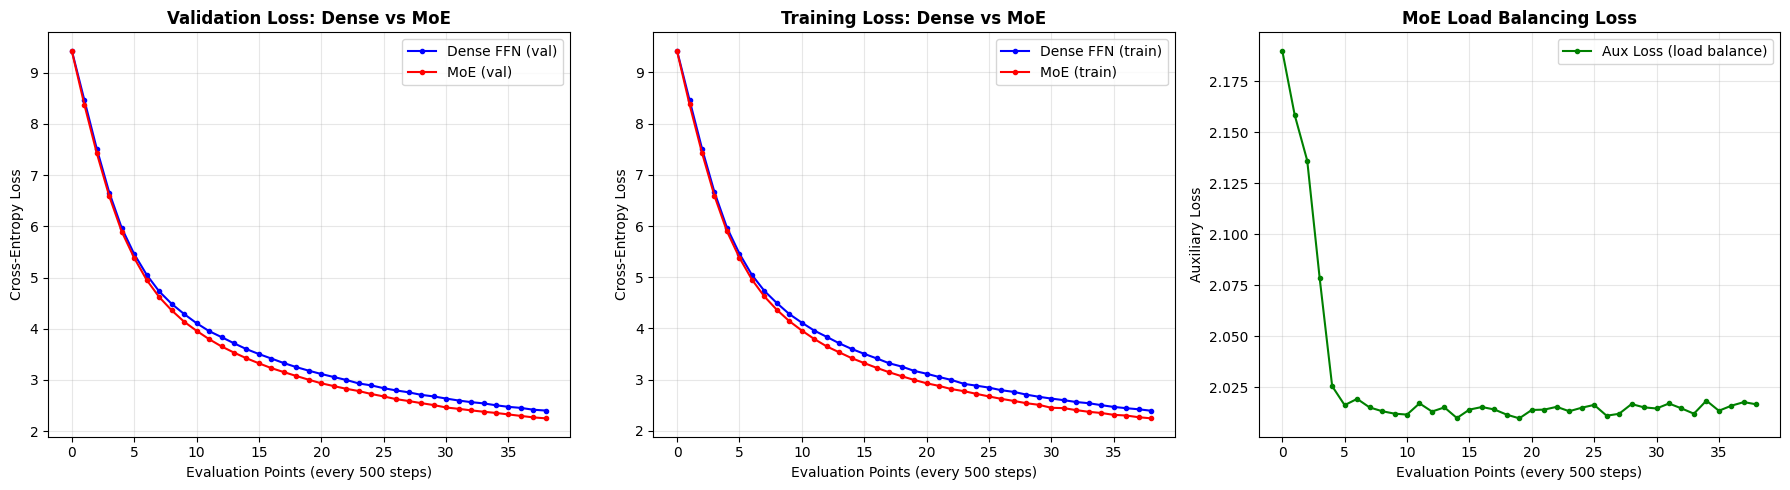


               FINAL RESULTS COMPARISON
Metric                                Dense          MoE
------------------------------------------------------------
Final Val Loss (CE)                  2.4022       2.2503
Best Val Loss (CE)                                2.2503
Total Parameters                     30.00M       51.27M
Active Params/Token                  30.00M       37.09M

MoE achieves 6.3% lower validation loss!


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ─── Plot 1: Validation Loss Comparison ───
ax = axes[0]
# Dense model losses (from Part 1)
dense_val_converted = [v.cpu().detach().item() if hasattr(v, 'cpu') else v for v in validation_loss_list]
# MoE model losses
moe_val_converted = [v.cpu().detach().item() if hasattr(v, 'cpu') else v for v in moe_val_loss_list]

eval_points_dense = list(range(len(dense_val_converted)))
eval_points_moe = list(range(len(moe_val_converted)))

ax.plot(eval_points_dense, dense_val_converted, 'b-o', label='Dense FFN (val)', markersize=3)
ax.plot(eval_points_moe, moe_val_converted, 'r-o', label='MoE (val)', markersize=3)
ax.set_xlabel(f'Evaluation Points (every {eval_iters} steps)')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Validation Loss: Dense vs MoE', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── Plot 2: Training Loss Comparison ───
ax = axes[1]
dense_train_converted = [v.cpu().detach().item() if hasattr(v, 'cpu') else v for v in train_loss_list]
moe_train_converted = [v.cpu().detach().item() if hasattr(v, 'cpu') else v for v in moe_train_loss_list]

ax.plot(dense_train_converted, 'b-o', label='Dense FFN (train)', markersize=3)
ax.plot(moe_train_converted, 'r-o', label='MoE (train)', markersize=3)
ax.set_xlabel(f'Evaluation Points (every {eval_iters} steps)')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training Loss: Dense vs MoE', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── Plot 3: MoE Auxiliary Loss ───
ax = axes[2]
moe_aux_converted = [v.cpu().detach().item() if hasattr(v, 'cpu') else v for v in moe_aux_loss_list]
ax.plot(moe_aux_converted, 'g-o', label='Aux Loss (load balance)', markersize=3)
ax.set_xlabel(f'Evaluation Points (every {eval_iters} steps)')
ax.set_ylabel('Auxiliary Loss')
ax.set_title('MoE Load Balancing Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Print Summary ───
print("\n" + "=" * 60)
print("               FINAL RESULTS COMPARISON")
print("=" * 60)
dense_final = dense_val_converted[-1] if dense_val_converted else float('nan')
moe_final = moe_val_converted[-1] if moe_val_converted else float('nan')
print(f"{'Metric':<30} {'Dense':>12} {'MoE':>12}")
print("-" * 60)
print(f"{'Final Val Loss (CE)':<30} {dense_final:>12.4f} {moe_final:>12.4f}")
print(f"{'Best Val Loss (CE)':<30} {'':>12} {best_moe_val_loss:>12.4f}")
print(f"{'Total Parameters':<30} {dense_params/1e6:>11.2f}M {moe_total_params/1e6:>11.2f}M")
print(f"{'Active Params/Token':<30} {dense_params/1e6:>11.2f}M {moe_active_params/1e6:>11.2f}M")
if moe_final < dense_final:
    improvement = (dense_final - moe_final) / dense_final * 100
    print(f"\nMoE achieves {improvement:.1f}% lower validation loss!")
else:
    print(f"\nDense model has lower loss — MoE may need more training or tuning.")


## Step 16: Run MoE Inference & Compare Generations

Let's generate text with the **same prompts** used for the dense model, and compare quality.


In [ ]:
# Load best MoE model
moe_model_infer = MoEGPT(moe_config)
moe_model_infer.load_state_dict(
    torch.load(best_moe_model_path, map_location=torch.device(device))
)
moe_model_infer = moe_model_infer.to(device)
moe_model_infer.eval()

# Also load best dense model for side-by-side comparison
dense_model_infer = GPT(config)
dense_model_infer.load_state_dict(
    torch.load(best_model_params_path, map_location=torch.device(device))
)
dense_model_infer = dense_model_infer.to(device)
dense_model_infer.eval()

print("Both models loaded for inference!")


Both models loaded for inference!


In [ ]:
# ─── Generate with both models ───
prompts = [
    "Once upon a time there was a pumpkin.",
    "A little girl went to the woods",
    "The cat sat on the mat and",
]

for prompt in prompts:
    context = torch.tensor(enc.encode_ordinary(prompt)).unsqueeze(0).to(device)

    print("=" * 70)
    print(f"PROMPT: {prompt}")
    print("=" * 70)

    # Dense model
    with torch.no_grad():
        y_dense = dense_model_infer.generate(context, 150, temperature=0.8, top_k=40)
    print(f"\n--- Dense FFN ---")
    print(enc.decode(y_dense.squeeze().tolist()))

    # MoE model
    with torch.no_grad():
        y_moe = moe_model_infer.generate(context, 150, temperature=0.8, top_k=40)
    print(f"\n--- MoE (4 experts, top-2) ---")
    print(enc.decode(y_moe.squeeze().tolist()))
    print()


PROMPT: Once upon a time there was a pumpkin.

--- Dense FFN ---
Once upon a time there was a pumpkin. It was a beautiful flag that was in the middle of the world! The pumpkin was so beautiful! Every day it would take a closer look and see what it would be like to do with its own.

One day, a little mouse came out from behind a tree. The stick was very strong and could not fit away. The rabbit was sad and wanted to go home. But the mouse kept running and laughing.

The mouse was very fast and he was very scared. It was so much fun! The mouse wanted to win, but it was too late. All the other animals on the castle were scared. The mouse was too scared of the mouse, but he didn't move.

But then someone realised that the mouse

--- MoE (4 experts, top-2) ---
Once upon a time there was a pumpkin. He wanted to eat it all day long. He tried to find all the things in the forest. He tried to find more things that were all around. He found a big pile of leaves, rocks and stones. All of a sudden

## Step 17: Analyze Expert Utilization

A healthy MoE model should use all experts **roughly equally**. If one expert dominates
(gets most tokens), that's called **expert collapse** — the other experts are wasted.

Let's check how our router distributes tokens across experts in each layer.


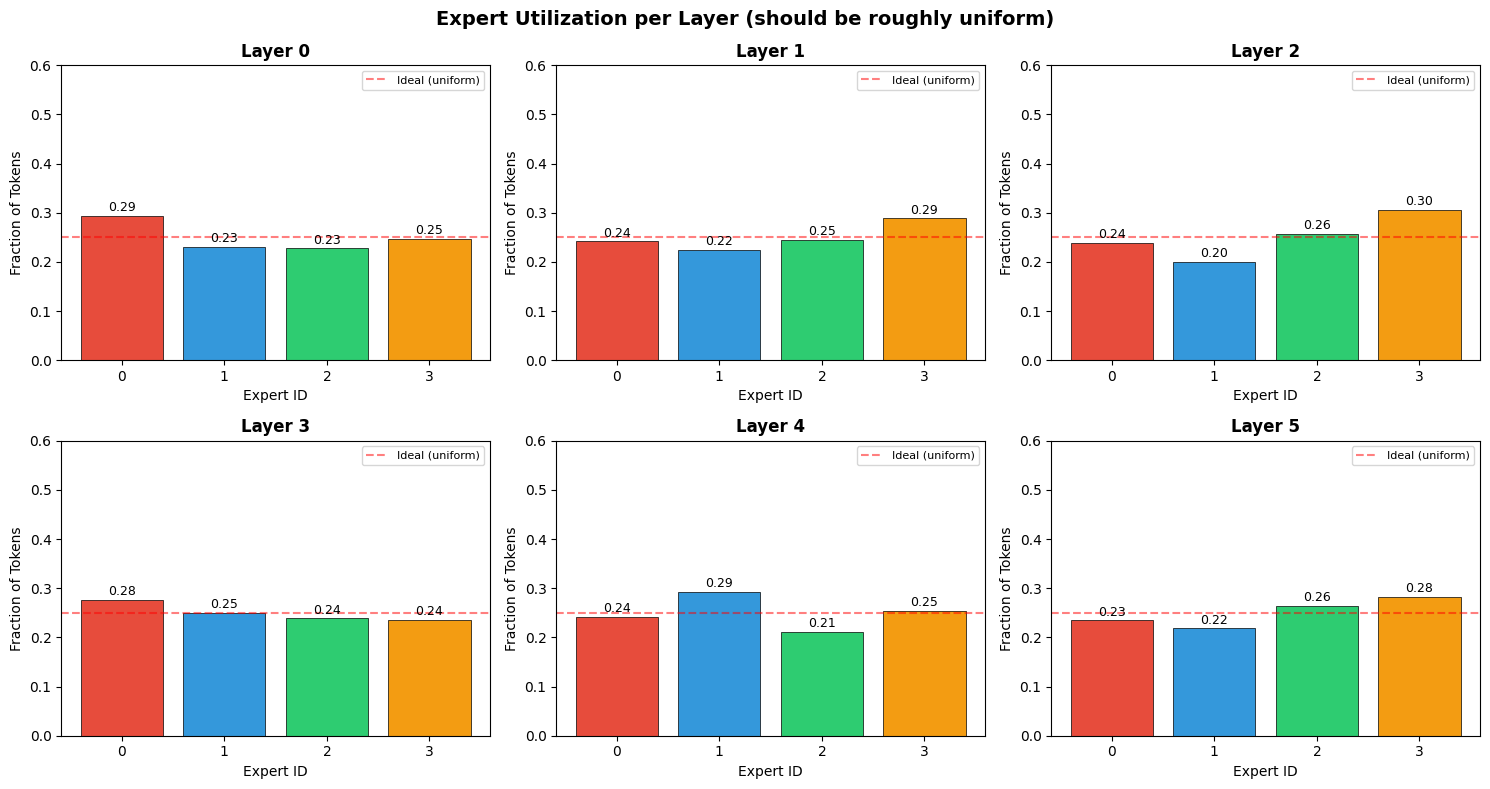


Ideal fraction per expert (uniform): 0.25
If all bars are close to the dashed line, the router is well-balanced!


In [ ]:
import matplotlib.pyplot as plt

moe_model_infer.eval()

# Collect routing decisions from multiple batches
expert_counts_per_layer = {i: torch.zeros(moe_config.num_experts) for i in range(moe_config.n_layer)}
num_analysis_batches = 50

with torch.no_grad():
    for _ in range(num_analysis_batches):
        X, _ = get_batch('val')
        x = moe_model_infer.transformer.drop(
            moe_model_infer.transformer.wte(X) +
            moe_model_infer.transformer.wpe(torch.arange(X.size(1), device=X.device))
        )

        for layer_idx, block in enumerate(moe_model_infer.transformer.h):
            # Run attention
            x_attn = x + block.attn(block.ln1(x))
            # Get routing decisions (without running experts)
            _, selected_experts, _ = block.moe.router(block.ln2(x_attn))
            # Count expert usage
            for e in range(moe_config.num_experts):
                expert_counts_per_layer[layer_idx][e] += (selected_experts == e).sum().cpu().float()
            # Run full block for next layer
            x, _ = block(x)

# ─── Plot expert utilization per layer ───
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Expert Utilization per Layer (should be roughly uniform)',
             fontsize=14, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for layer_idx in range(moe_config.n_layer):
    ax = axes[layer_idx // 3][layer_idx % 3]
    counts = expert_counts_per_layer[layer_idx]
    fractions = counts / counts.sum()

    bars = ax.bar(range(moe_config.num_experts), fractions.cpu().numpy(),
                  color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(y=1.0/moe_config.num_experts, color='red', linestyle='--',
               alpha=0.5, label='Ideal (uniform)')
    ax.set_title(f'Layer {layer_idx}', fontweight='bold')
    ax.set_xlabel('Expert ID')
    ax.set_ylabel('Fraction of Tokens')
    ax.set_ylim(0, 0.6)
    ax.set_xticks(range(moe_config.num_experts))
    ax.legend(fontsize=8)

    for i, frac in enumerate(fractions):
        ax.text(i, frac.cpu().item() + 0.01, f'{frac.cpu().item():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nIdeal fraction per expert (uniform):", f"{1.0/moe_config.num_experts:.2f}")
print("If all bars are close to the dashed line, the router is well-balanced!")

## Key Takeaways

1. **MoE replaces the single FFN with multiple expert FFNs + a router**.
   Each token only uses top-k experts, making computation sparse.

2. **More capacity, similar compute**: Our MoE model has ~1.7x more total parameters
   but only ~1.2x more active compute per token. This is the core MoE advantage.

3. **Load balancing loss is essential**: Without it, the router might send all tokens
   to one expert (expert collapse), wasting the other experts entirely.

4. **The router learns specialization**: Over training, different experts learn to handle
   different types of tokens/contexts — that's where the quality gains come from.

5. **Scaling potential**: Real MoE models (DeepSeek-V3: 256 experts, Mixtral: 8 experts)
   use expert parallelism to distribute experts across GPUs. Our single-GPU implementation
   shows the concept; EP makes it practical at scale.


In [ ]:
from google.colab import runtime
runtime.unassign()